# ROC Curve

Conda environment for this notebook: `conda env create`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotting
# standardize colors
from cycler import cycler 
plt.rcParams['axes.prop_cycle'] = cycler('color', [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a"])

Just a simple diagram for explaining the ROC-curve with a perfect curve, an uninformative (basically random), and examples from the saved data in "testmodel"

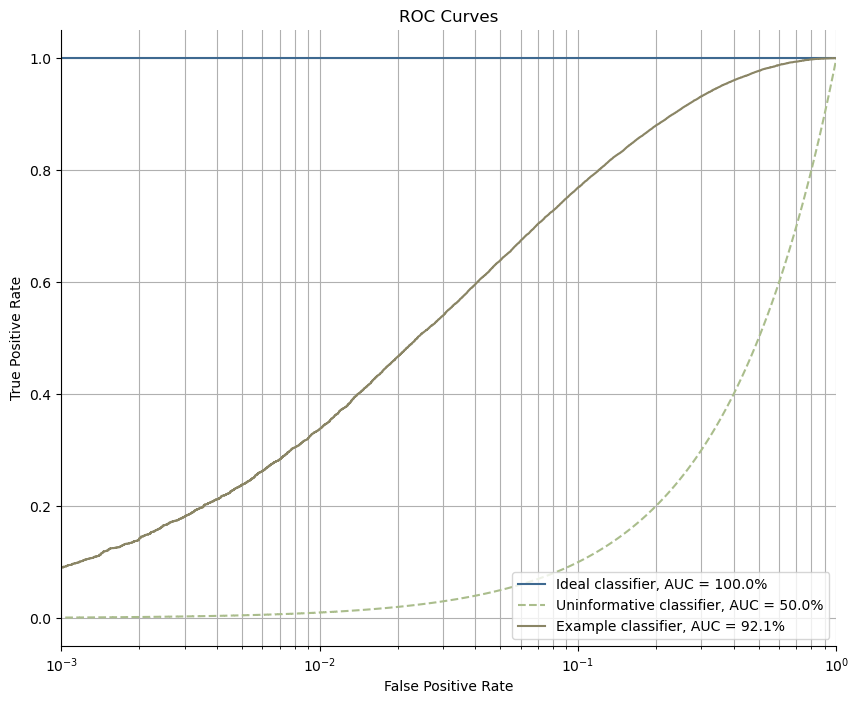

In [2]:
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../testmodel/y_keras.npy")

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-")
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--")
plotting.makeRoc(y_true, y_example, ["Example classifier"], linestyle="-")
plt.title("ROC Curves")
plt.show()

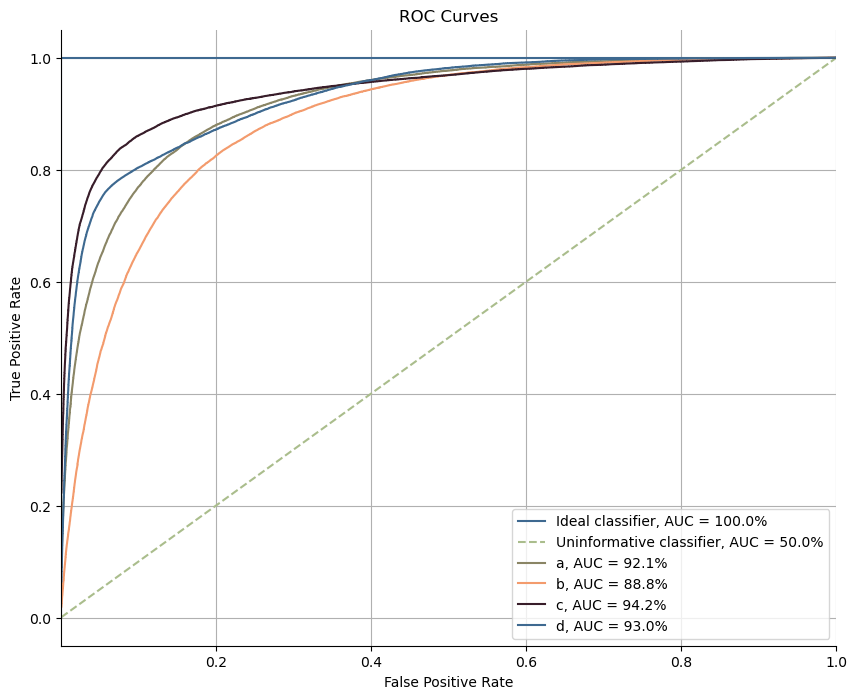

In [3]:
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../testmodel/y_keras.npy")
example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-", style_semilogx=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", style_semilogx=False)
plotting.makeRoc(y_true, y_example, ["a","b","c","d"], linestyle="-", style_semilogx=False)
plt.title("ROC Curves")
plt.show()

Put side by side

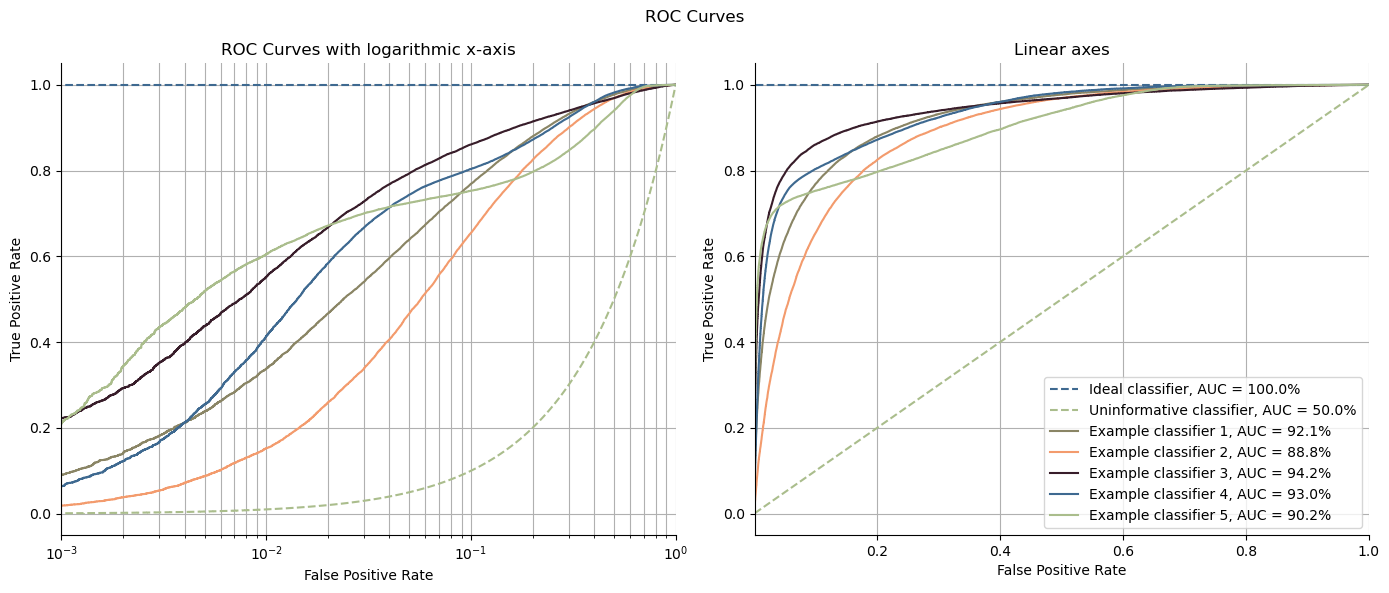

In [ ]:
# Side-by-side duplicate of the two ROC examples
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

y_example = np.load("../testmodel/y_keras.npy")
#example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)
example_classes = ["Example classifier 1", "Example classifier 2", "Example classifier 3", "Example classifier 4", "Example classifier 5"]

y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curves")

plt.sca(axs[0])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", legend=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", legend=False)
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", style_semilogx=False, legend=False)
axs[0].set_title("ROC Curves with logarithmic x-axis")

plt.sca(axs[1])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", style_semilogx=False, style_legends='default')
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", style_semilogx=False, style_legends='default')
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", style_semilogx=False, style_legends='default')
axs[1].set_title("Linear axes")

plt.tight_layout()
plt.show()

In [5]:
nrows, ncols = 2, 3

colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]

config = [
    {"labelname": "MNIST CNN HGQ StaticTraining", "filepath": "../MNIST/CNN_HGQ_StaticTraining/MNIST_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST CNN HGQ DynamicTraining", "filepath": "../MNIST/CNN_HGQ_DynamicTraining/MNIST_CNN_HGQ_DynamicTraining_log.csv"},
    {"labelname": "MNIST MLP HGQ StaticTraining", "filepath": "../MNIST/MLP_HGQ_StaticTraining/MNIST_MLP_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST MLP HQG DynamicTraining", "filepath": "../MNIST/MLP_HGQ_DynamicTraining/MNIST_MLP_HQG_DynamicTraining_log.csv"},
    {"labelname": "JET HGQ Training", "filepath": "../JET_HGQ_Training_log.csv"},
]

data = [
    {
        "labelname": line["labelname"],
        "dataframe": pd.read_csv(line['filepath'], sep=';', index_col=0),
    }
    for line in config
]

data[0]
#df = data[1]["dataframe"]
#df[:10]

NameError: name 'pd' is not defined

### Accuracy over Ebops

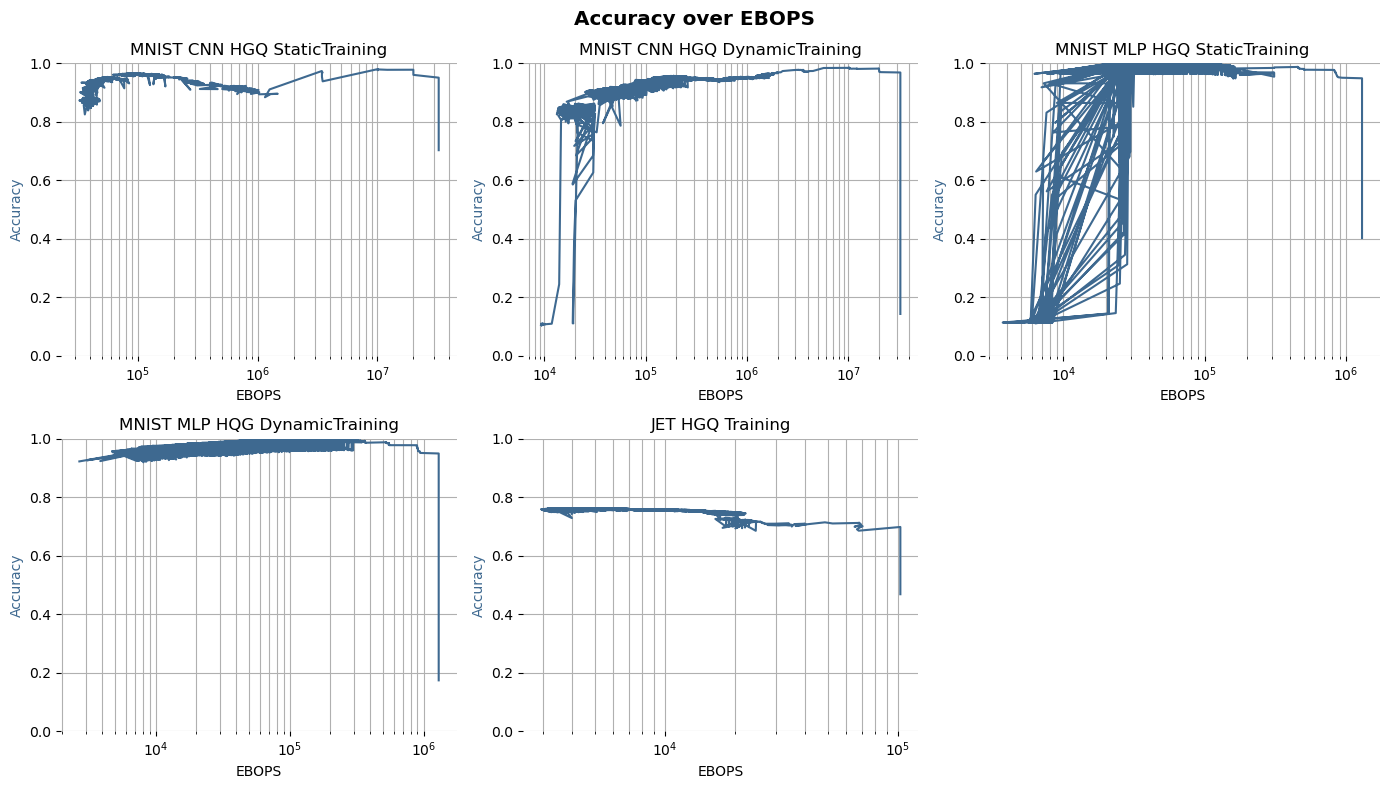

In [6]:
plotname = "Accuracy over EBOPS"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 8))
axs = axs.flatten()

for i, item in enumerate(data):
    #ax = axs[i // 3, i % 3] # flattened instead
    ax1 = axs[i]
    df = item['dataframe']

    #ax1.plot('ebops', 'accuracy', data=df, color=colors[0])
    ax1.semilogx('ebops', 'accuracy', data=df, color=colors[0])
    ax1.set_ylim(0, 1)
    ax1.grid(True, which='both')

    ax1.set_title(item['labelname'])
    ax1.set_xlabel('EBOPS')
    ax1.set_ylabel('Accuracy', color=colors[0])

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)

    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')


plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

Same graph, but plotted over each other for direct comparison. By selecting thresholds in EBOPS or accuracy, you may visualize which model may be the best fit.

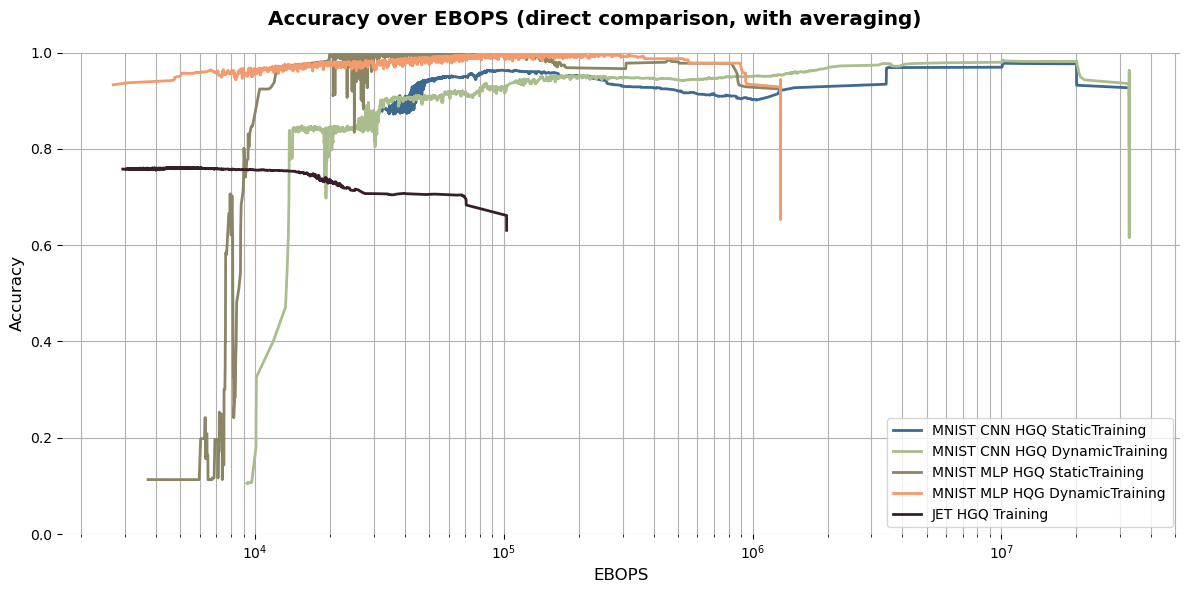

In [7]:
plotname = "Accuracy over EBOPS (direct comparison, with averaging)"
fig, ax = plt.subplots(figsize=(12, 6))

# moving average filter / lavpassfilter for smoothing the colossal amount of data
window_size = 10

for i, item in enumerate(data):
    df = item['dataframe'].sort_values('ebops')
    df_smooth = df.copy()
    df_smooth['accuracy'] = df['accuracy'].rolling(window=window_size, center=True, min_periods=1).mean()
    ax.semilogx('ebops', 'accuracy', data=df_smooth, color=colors[i], label=item['labelname'], linewidth=2)

ax.set_ylim(0, 1)
ax.set_xlabel('EBOPS', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.grid(True, which='both')#, axis='x')
ax.legend(loc='best', fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

### Accuracy and EBOPS over Epochs (timeseries)

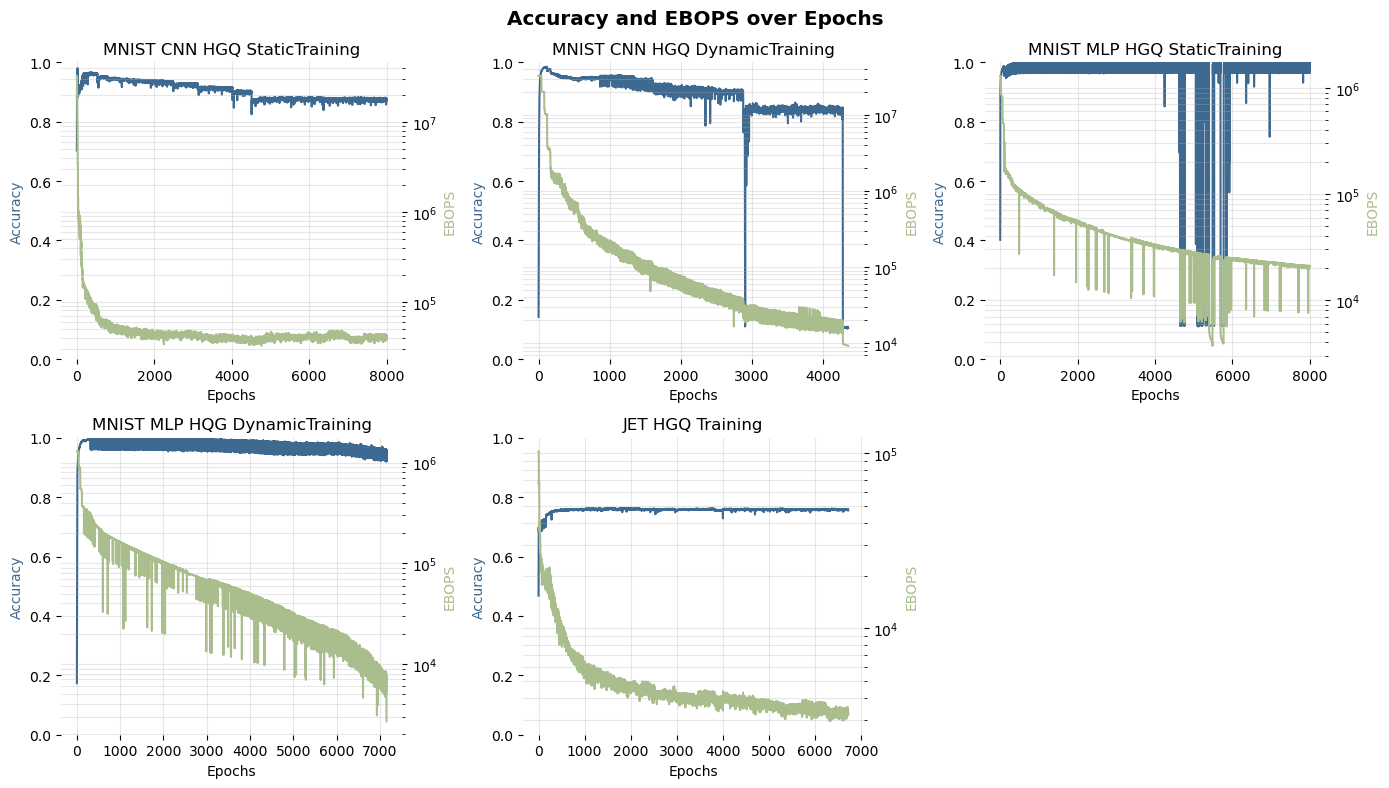

In [9]:
plotname = "Accuracy and EBOPS over Epochs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 8))
axs = axs.flatten()


for i, item in enumerate(data):
    ax1 = axs[i]
    ax2 = ax1.twinx()
    df = item['dataframe']


    ax1.plot(df.index, 'accuracy', data=df, color=colors[0])
    ax1.set_ylim(0, 1)

    ax2.set_ylabel('EBOPS', color=colors[1])
    ax2.semilogy(df.index, 'ebops', data=df, color=colors[1])

    ax1.set_title(item['labelname'])
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy', color=colors[0])
    ax1.grid(True, which='both', alpha=0.3, axis='x')
    ax2.grid(True, which='both', alpha=0.3)

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["bottom"].set_visible(False)
    #ax2.grid()
    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')

    
plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")


# Annotations https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotate_transform.html
# Minimalistic https://practicaldatascience.org/notebooks/class_5/week_1/2.2.2_making_plots_pretty_2.html